In [ ]:
# fraud detection

predicted : [1]
accuracy_score: 1.0
confusion_matrix:
: [[1]]
classification_report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


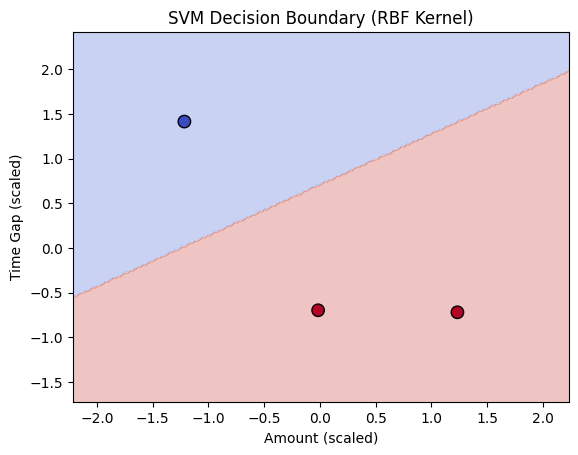

In [10]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# create a dataset

data = {
    'amount': [5000, 200, 10000],
    'time_gap': [1, 48, 0.5],
    'location_change': [1, 0, 1],
    'fraud': [1, 0, 1]
}

df = pd.DataFrame(data)

x = df[['amount', 'time_gap', 'location_change' ]]

y = df['fraud']

# train and test the data

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

# feature standard scaler

std = StandardScaler()
x_train_scaler = std.fit_transform(x_train)
x_test_scaler = std.transform(x_test)

# fit svm as svc

model = SVC(C = 10, kernel = 'rbf', gamma = 0.1)
model.fit(x_train_scaler, y_train)

# prediction 

pred = model.predict(x_test_scaler)

# Elevation

print("predicted :", pred)
print("accuracy_score:", accuracy_score(y_test, pred))
print("confusion_matrix:\n:", confusion_matrix(y_test, pred))
print("classification_report:\n", classification_report(y_test, pred))

import matplotlib.pyplot as plt
import numpy as np

# Only use first two features for visualization (amount, time_gap)
X_vis = x[['amount', 'time_gap']]
y_vis = y

# Scale them
X_vis_scaled = std.fit_transform(X_vis)

# Fit again for visualization
model_vis = SVC(C=10, kernel='rbf', gamma=0.1)
model_vis.fit(X_vis_scaled, y_vis)

# Create a mesh grid
x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict over the grid
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis, s=80, cmap=plt.cm.coolwarm, edgecolors='k')

plt.xlabel("Amount (scaled)")
plt.ylabel("Time Gap (scaled)")
plt.title("SVM Decision Boundary (RBF Kernel)")
plt.show()

In [ ]:
# large  spam sms dataset

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load dataset
df = pd.read_csv("SMSSpamCollection", sep="\t", names=["label", "message"])

# 2. Encode labels (ham = 0, spam = 1)
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

# 3. Feature extraction using TF-IDF
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["message"])
y = df["label_num"]

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Standardization (not strictly needed for sparse TF-IDF, but shown for completeness)
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train SVM classifier
svm = SVC(kernel="linear", C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)

# 7. Predictions
y_pred = svm.predict(X_test_scaled)

# 8. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("confusion_matric:\n",confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9748878923766816
confusion_matric:
 [[964   2]
 [ 26 123]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       0.98      0.83      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



Dataset shape: (5572, 2)
Class distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64

Sample messages:
      label                                            message
2334   ham                  What happen to her tell the truth
2208   ham  Usually the body takes care of it buy making s...
3908   ham             No that just means you have a fat head
1875  spam  Would you like to see my XXX pics they are so ...
1894   ham                       Good Morning plz call me sir

Accuracy: 0.97847533632287

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



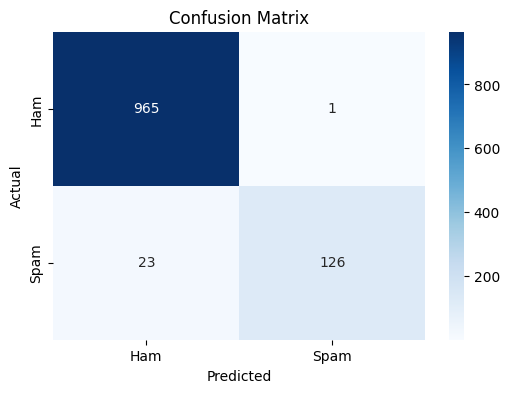


Model saved as spam_svm_model.pkl
Message: Congratulations! You've won a free ticket! --> Ham
Message: Hey, are we meeting tomorrow? --> Ham


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
import joblib

# 1. Load dataset
df = pd.read_csv("SMSSpamCollection", sep="\t", names=["label", "message"])

# Inspect data
print("Dataset shape:", df.shape)
print("Class distribution:\n", df["label"].value_counts())
print("\nSample messages:\n", df.sample(5))

# 2. Encode labels
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label_num"], test_size=0.2, random_state=42, stratify=df["label_num"]
)

# 4. Build pipeline (TF-IDF + Scaling + SVM)
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("scaler", StandardScaler(with_mean=False)),
    ("svm", SVC(kernel="linear", C=1.0, random_state=42))
])

# 5. Train model
pipeline.fit(X_train, y_train)

# 6. Predictions
y_pred = pipeline.predict(X_test)

# 7. Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham","Spam"], yticklabels=["Ham","Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 8. Save model
joblib.dump(pipeline, "spam_svm_model.pkl")
print("\nModel saved as spam_svm_model.pkl")

# 9. Example prediction
sample_texts = ["Congratulations! You've won a free ticket!", "Hey, are we meeting tomorrow?"]
predictions = pipeline.predict(sample_texts)
for text, pred in zip(sample_texts, predictions):
    print(f"Message: {text} --> {'Spam' if pred==1 else 'Ham'}")

In [ ]:
# Credit Card Fraud Detection (Imbalanced Classification)

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.metrics import recall_score

# read a dataset file

df = pd.read_csv("creditcard.csv")

x = df.drop("Class", axis = 1)

y = df["Class"]

# Train_Test_Split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# features scaling

scale = StandardScaler()
x_train_scl = scale.fit_transform(x_train)
x_test_scl = scale.transform(x_test)

#  svm

svm = SVC(class_weight = 'balanced', random_state = 42, kernel = 'rbf')
svm.fit(x_train_scl, y_train)
pred_svm = svm.predict(x_test_scl)
print("svm_model_value:", pred_svm)
print("svm accuracy_score:\n", accuracy_score(y_test, pred_svm))
print("svm confusion_matrix:\n", confusion_matrix(y_test, pred_svm))
print("svm classification_report:\n", classification_report(y_test, pred_svm))

# logistic regression

log = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
log.fit(x_train_scl, y_train)
pred_log = log.predict(x_test_scl)
print("logistic_regression_value:", pred_log)
print("log accuracy_score:\n", accuracy_score(y_test, pred_log))
print("log confusion_matrix:\n", confusion_matrix(y_test, pred_log))
print("log classification_report:\n", classification_report(y_test, pred_log))


# Recall_score

print("SVM Recall:", recall_score(y_test, pred_svm))
print("Logistic Regression Recall:", recall_score(y_test, pred_log))



svm_model_value: [0 0 0 ... 0 0 0]
svm accuracy_score:
 0.9970155542291352
svm confusion_matrix:
 [[56719   145]
 [   25    73]]
svm classification_report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.33      0.74      0.46        98

    accuracy                           1.00     56962
   macro avg       0.67      0.87      0.73     56962
weighted avg       1.00      1.00      1.00     56962

logistic_regression_value: [1 0 0 ... 0 0 1]
log accuracy_score:
 0.9764053228468101
log confusion_matrix:
 [[55528  1336]
 [    8    90]]
log classification_report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

SVM Recall: 0.74489795